In [ ]:
import numpy as np
import sympy as sp
import matplotlib as mp
import matplotlib.pyplot as plt
import scipy as scy

In [ ]:
# This is coded in a similar way to how I have previously done it, but due to the larger scale of points being considered,
# this would not work well for any large values. This led me to use a sparse matrix with fewer/smaller for loops
# which greatly reduced the time needed to run the code.
def CalculMat3D(N):
    # Create empty array
    A = np.zeros((N**3, N**3))
    h = 1/(N+1)
    # Cycling through each point in the array
    for i in range(N**3):
        for j in range(N**3):
            # Fill the diagonal with 4s
            if i == j:
                A[i,j] = 6/h**2

            # Fill the +-1 diagonals with -1s
            if i == j+(N**2) or i == j-(N**2):
                A[i,j] = -1/h**2

            # Fill the N diagonals with -1s for values above/below the 4s in the grid
            if i == j+N or i == j-N:
                if i//N**2 == j//N**2:
                    A[i,j] = -1/h**2

            if i == j+1 or i == j-1:
                # // divides and rounds down.
                # This can be used such that any point along this diagonal where i is a different value to j will return 0
                if i // N == j // N: 
                    A[i,j] = -1/h**2
    return A

In [ ]:
# Input values for the conductivity of the different materials 
k_air = 0.025 # Approximate conductivity of air
k_floor = 2 # Aproximate conductivity of tarmac

In [219]:
def CalculMat3D(N):
    # Create empty array
    A = scy.sparse.lil_matrix((N**3, N**3))
    h = 1/(N+1)
    # Cycling through each point in the array
    for i in range(N**3):
        if i < N**2: # Looking at the tarmac layer which has a different k_value to the air
            A[i,i] = 6*k_floor/h**2
            # Fill the +-N**2 diagonals with -1s
            # These are the z neighbours
            for j in [i-N**2, i+N**2]:
                if 0 <= j < N**3:
                    A[i,j] = -k_floor/h**2

            # Fill the +-N diagonals with -1s 
            # These are the y neighbours
            for j in [i-N, i+N]:
                if 0 <= j < N**3:
                    # This can be used such that any point along this diagonal where i is in a different area(plane) to j will return 0
                    if i//N**2 == j//N**2:
                        A[i,j] = -k_floor/h**2
            
            # Fill the +-1 diagonals with -1s
            # These are the x neighbours
            for j in [i-1, i+1]:
                if 0 <= j < N**3:
                # // divides and rounds down.
                # This can be used such that any point along this diagonal where i is in a different area(row) to j will return 0
                    if i // N == j // N: 
                        A[i,j] = -k_floor/h**2

        else:
            # Fill the diagonal with 4s
            A[i,i] = 6*k_air/h**2
            # Fill the +-N**2 diagonals with -1s
            # These are the z neighbours
            for j in [i-N**2, i+N**2]:
                if 0 <= j < N**3:
                    A[i,j] = -k_air/h**2

            # Fill the +-N diagonals with -1s 
            # These are the y neighbours
            for j in [i-N, i+N]:
                if 0 <= j < N**3:
                    # This can be used such that any point along this diagonal where i is in a different area(plane) to j will return 0
                    if i//N**2 == j//N**2:
                        A[i,j] = -k_air/h**2
            
            # Fill the +-1 diagonals with -1s
            # These are the x neighbours
            for j in [i-1, i+1]:
                if 0 <= j < N**3:
                # // divides and rounds down.
                # This can be used such that any point along this diagonal where i is in a different area(row) to j will return 0
                    if i // N == j // N: 
                        A[i,j] = -k_air/h**2
    return A.tocsr()

In [220]:
# Function that takes coordinates for a certain size and outputs the single value they represent.
def I(i,j,k,n):
    return i + j*(n) +k*(n**2)

In [221]:
def CalculRHS3D(N):
    Bh = np.zeros(N**3) 
    h = 1 / (N + 1)
    
    # Cycling through each point in the array
    for i in range(N):
        for j in range(N):
            for k in range(N):
                # Find value for point n in array Bh which is from the 3D coordinates k,j,i
                n = I(i, j, k, N)
                # Define x_i and y_j
                x = (i+1) * h
                y = (j+1)*h

                if (x-0.5)**2 + (y-0.5)**2 < 0.2**2:
                    if k == 0:
                        Bh[n] = 50
                    
                    else:
                        Bh[n] = 5*0.001

                elif k == 0:
                    Bh[n] = 15
                
                    
    return Bh

In [222]:
n = 30 # Choose a value for N

# I had to use a different solve function, as the original wouldn't work with a sparse matrix.
Uh = scy.sparse.linalg.spsolve(CalculMat3D(n), CalculRHS3D(n))

# Creating an empty array to display final solution
T = np.zeros((n, n, n))
# Inputting each value into the correct coordinate to allow easier plotting.
for i in range(n):
    for j in range(n):
        for k in range(n):
                T[i, j, k] = Uh[I(j, i, k, n)]

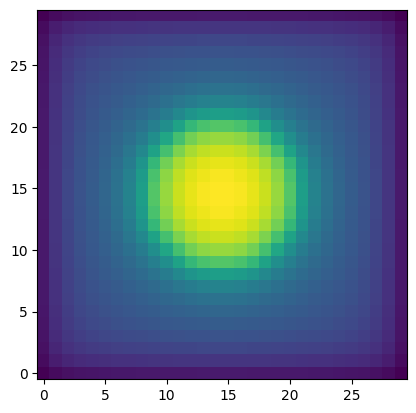

In [227]:
# A short function that allowed me to look at specific slices of the heat
def z_slice(U, slice):
    plt.imshow(U[:,:, slice], origin = "lower")
    plt.show()

z_slice(T, 1)

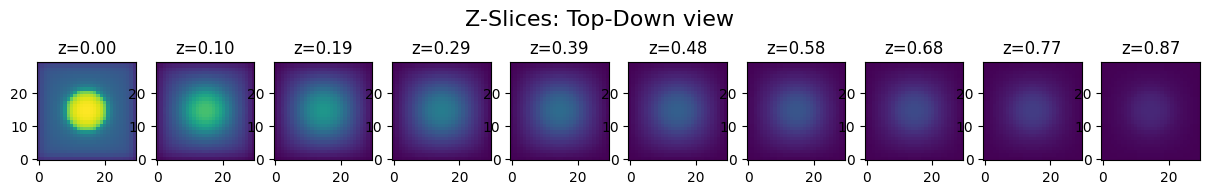

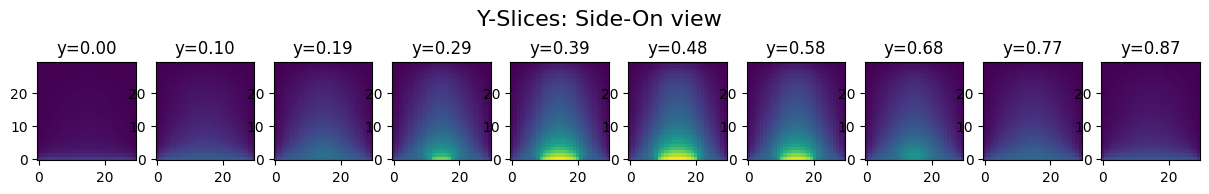

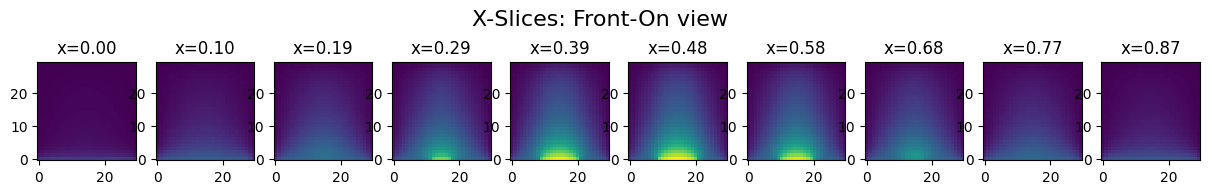

In [224]:
# Adding a global max and min, so that the heatmaps are comparable and make a more full picture
global_min = T.min()
global_max = T.max()

# AI used to add titles and ensure each axis is the correct way round
fig, axes = plt.subplots(1, 10, figsize = (n/2, 4))
fig.suptitle('Z-Slices: Top-Down view', fontsize=16, y=0.75)
for i in range(10):
    axes[i].imshow(T.T[round((n/10)*(i)), :, :], origin = "lower", vmin = global_min, vmax = global_max)
    axes[i].set_title(f"z={(i*n/10)*(1/(n+1)):.2f}")
fig, axes = plt.subplots(1, 10, figsize = (n/2, 4))
fig.suptitle('Y-Slices: Side-On view', fontsize=16, y=0.75)
for i in range(10):
    axes[i].imshow(T.T[:,round((n/10)*(i)),:], origin = "lower", vmin = global_min, vmax = global_max)
    axes[i].set_title(f"y={(i*n/10)*(1/(n+1)):.2f}")
fig, axes = plt.subplots(1, 10, figsize = (n/2, 4))
fig.suptitle('X-Slices: Front-On view', fontsize=16, y=0.75)
for i in range(10):
    axes[i].imshow(T.T[:, :, round((n/10)*(i))], origin = "lower", vmin = global_min, vmax = global_max)
    axes[i].set_title(f"x={(i*n/10)*(1/(n+1)):.2f}")
